In [3]:
# Importing the required Modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
%matplotlib inline

In [4]:
# Importing the DataFrame
df = pd.read_csv('./raw_house_data.csv')
df.head()

,MLS,sold_price,zipcode,longitude,latitude,lot_acres,taxes,year_built,bedrooms,bathrooms,sqrt_ft,garage,kitchen_features,fireplaces,floor_covering,HOA
0,21530491,5300000.0,85637,-110.378200,31.356362,2154.00,5272.00,1941,13,10.0,10500.0,0.0,"Dishwasher, Freezer, Refrigerator, Oven",6,"Mexican Tile, Wood",0
1,21529082,4200000.0,85646,-111.045371,31.594213,1707.00,10422.36,1997,2,2.0,7300.0,0.0,"Dishwasher, Garbage Disposal",5,"Natural Stone, Other",0
2,3054672,4200000.0,85646,-111.040707,31.594844,1707.00,10482.00,1997,2,3.0,NaN,NaN,"Dishwasher, Garbage Disposal, Refrigerator",5,"Natural Stone, Other: Rock",NaN
3,21919321,4500000.0,85646,-111.035925,31.645878,636.67,8418.58,1930,7,5.0,9019.0,4.0,"Dishwasher, Double Sink, Pantry: Butler, Refri...",4,"Ceramic Tile, Laminate, Wood",NaN
4,21306357,3411450.0,85750,-110.813768,32.285162,3.21,15393.00,1995,4,6.0,6396.0,3.0,"Dishwasher, Garbage Disposal, Refrigerator, Mi...",5,"Carpet, Concrete",55


In [5]:
df.describe(include = 'all')

,MLS,sold_price,zipcode,longitude,latitude,lot_acres,taxes,year_built,bedrooms,bathrooms,sqrt_ft,garage,kitchen_features,fireplaces,floor_covering,HOA
count,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5000.000000,4990.000000,5.000000e+03,5000.00000,5000.000000,4994.000000,4944.000000,4993.000000,4967,5000,4999,4438
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1871,11,310,380
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Dishwasher, Garbage Disposal, Refrigerator, Mi...",1,"Carpet, Ceramic Tile",0
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1719,1806,1235,824
mean,2.127070e+07,7.746262e+05,85723.025600,-110.912107,32.308512,4.661317,9.402828e+03,1992.32800,3.933800,3.829896,3716.366828,2.816143,NaN,NaN,NaN,NaN
std,2.398508e+06,3.185556e+05,38.061712,0.120629,0.178028,51.685230,1.729385e+05,65.48614,1.245362,1.387063,1120.683515,1.192946,NaN,NaN,NaN,NaN
min,3.042851e+06,1.690000e+05,85118.000000,-112.520168,31.356362,0.000000,0.000000e+00,0.00000,1.000000,1.000000,1100.000000,0.000000,NaN,NaN,NaN,NaN
25%,2.140718e+07,5.850000e+05,85718.000000,-110.979260,32.277484,0.580000,4.803605e+03,1987.00000,3.000000,3.000000,3047.000000,2.000000,NaN,NaN,NaN,NaN
50%,2.161469e+07,6.750000e+05,85737.000000,-110.923420,32.318517,0.990000,6.223760e+03,1999.00000,4.000000,4.000000,3512.000000,3.000000,NaN,NaN,NaN,NaN
75%,2.180480e+07,8.350000e+05,85749.000000,-110.859078,32.394334,1.757500,8.082830e+03,2006.00000,4.000000,4.000000,4130.250000,3.000000,NaN,NaN,NaN,NaN


In [6]:
#replace all None, nan and '' with np.nan

df.replace(['None','','nan','NaN'],np.nan,inplace=True)

In [7]:
#fireplaces and HOA are numeric. We can convert them into numeric
numeric_convertion = ['fireplaces','HOA']
for feature in numeric_convertion:
    df[feature] = pd.to_numeric(df[feature], errors='coerce')

In [8]:
# Seeing the features with nulls
[features for features in df.columns if df[features].isnull().sum()>0]

['lot_acres',
 'bathrooms',
 'sqrt_ft',
 'garage',
 'kitchen_features',
 'fireplaces',
 'floor_covering',
 'HOA']

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

In [10]:
df_numeric_filled = df[numeric_cols].fillna(df[numeric_cols].median())


In [11]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


In [12]:
df_cat_filled = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])


In [13]:
df_filled = pd.concat([df_numeric_filled, df_cat_filled], axis=1)


In [14]:
#Clearly there are some outliers, we need to remove them
def remove_outliers(df,column):
    Q1 = df[column].quantile(0.25) 
    Q3 = df[column].quantile(0.75) 
    IQR = Q3-Q1
    lower_fence = Q1-1.5*(IQR)
    upper_fence = Q3+1.5*(IQR)
    return df[(df[column]>=lower_fence) & (df[column]<=upper_fence)]


In [15]:
features=["sold_price", "lot_acres",  "sqrt_ft"]
for feature in features:
    if df_filled[feature].dtype !='O':
        df_filled=remove_outliers(df_filled,feature)

In [16]:
df_filled = df_filled.reset_index(drop=True)

In [17]:
df = df_filled
df

,MLS,sold_price,zipcode,longitude,latitude,lot_acres,taxes,year_built,bedrooms,bathrooms,sqrt_ft,garage,fireplaces,HOA,kitchen_features,floor_covering
0,21125313,1100000.0,85755,-110.992897,32.461571,1.39,19156.00,2001,4,4.0,5164.0,3.0,4.0,153.0,"Dishwasher, Freezer, Garbage Disposal, Refrige...","Carpet, Natural Stone"
1,21529252,1200000.0,85750,-110.844774,32.326842,1.21,10610.26,2002,4,4.0,4426.0,3.0,0.0,117.0,"Dishwasher, Garbage Disposal, Refrigerator, Mi...",Natural Stone
2,21228820,1120150.0,85658,-111.060142,32.456128,2.98,13573.00,2007,4,6.0,4050.0,4.0,2.0,149.0,"Dishwasher, Refrigerator, Microwave, Oven","Carpet, Natural Stone, Wood"
3,21602274,1175000.0,85658,-111.099960,32.470520,0.33,11407.46,2008,3,4.0,3388.0,2.0,2.0,550.0,"Dishwasher, Refrigerator, Microwave, Oven",Wood
4,21221499,1189550.0,85658,-111.100125,32.469548,0.29,845.18,2010,3,4.0,2990.0,3.0,2.0,550.0,"Dishwasher, Garbage Disposal, Refrigerator, Mi...","Carpet, Concrete, Natural Stone, Wood"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3818,3056450,525000.0,85614,-110.980945,31.824287,3.01,5122.84,2007,3,3.0,3512.0,3.0,1.0,37.0,"Dishwasher, Garbage Disposal, Gas Range, Refri...","Concrete, Other: Cork"
3819,21908358,565000.0,85750,-110.820216,32.307646,0.83,4568.71,1986,4,3.0,2813.0,2.0,2.0,6.0,"Dishwasher, Double Sink, Electric Range, Garba...","Carpet, Mexican Tile"
3820,21909379,535000.0,85718,-110.922291,32.317496,0.18,4414.00,2002,3,2.0,2106.0,2.0,1.0,198.0,"Dishwasher, Double Sink, Electric Range, Garba...",Ceramic Tile
3821,21908591,550000.0,85750,-110.858556,32.316373,1.42,4822.01,1990,4,3.0,2318.0,3.0,1.0,43.0,"Dishwasher, Double Sink, Electric Range, Garba...","Carpet, Ceramic Tile"


In [18]:
df['price_per_sqft']=df['sold_price']//df['sqrt_ft']

In [19]:
df['price_per_sqft_nor']=df['price_per_sqft']//50

In [20]:
df["region"] = pd.qcut(df["price_per_sqft"], q=16, labels=False)

In [21]:
sub_df=df[['sold_price','latitude','longitude','price_per_sqft_nor']]

In [22]:
sub_df

,sold_price,latitude,longitude,price_per_sqft_nor
0,1100000.0,32.461571,-110.992897,4.0
1,1200000.0,32.326842,-110.844774,5.0
2,1120150.0,32.456128,-111.060142,5.0
3,1175000.0,32.470520,-111.099960,6.0
4,1189550.0,32.469548,-111.100125,7.0
...,...,...,...,...
3818,525000.0,31.824287,-110.980945,2.0
3819,565000.0,32.307646,-110.820216,4.0
3820,535000.0,32.317496,-110.922291,5.0
3821,550000.0,32.316373,-110.858556,4.0


In [23]:
X=sub_df.to_numpy()

In [24]:
y = X[:,-1]
y

array([4., 5., 5., ..., 5., 4., 2.], shape=(3823,))

In [25]:
X=X[:,1:-1]
X

array([[  32.461571, -110.992897],
       [  32.326842, -110.844774],
       [  32.456128, -111.060142],
       ...,
       [  32.317496, -110.922291],
       [  32.316373, -110.858556],
       [  32.296871, -111.055528]], shape=(3823, 2))

In [26]:
class KNNClassifier():

  def fit(self, X,y):
    self.X=X
    self.y=y

  def predict(self, X, K, epsilon=1e-3):

    N=len(X)
    y_hat = np.zeros(N)

    for i in range(N):
      dist2 = np.sum((self.X-X[i])**2, axis=1)
      idxt  = np.argsort(dist2)[:K]
      gamma_k = 1/(np.sqrt(dist2[idxt]+epsilon))

      y_hat[i] = np.bincount(self.y[idxt].astype(int), weights = gamma_k).argmax()

    return y_hat
 

In [27]:

knn_location = KNNClassifier()
knn_location.fit(X, y)



In [28]:
y_hat = knn_location.predict(X, K=10)


In [29]:

def accuracy(y, y_hat):
    return np.mean(y == y_hat)

print("KNN Accuracy:", accuracy(y, y_hat))

KNN Accuracy: 0.6303949777661523


In [30]:
X_test = [[-32.221680, -110.781160]]
y_test = knn_location.predict(X_test, 10)
print("Predicted region for test house:", y_test)


Predicted region for test house: [3.]


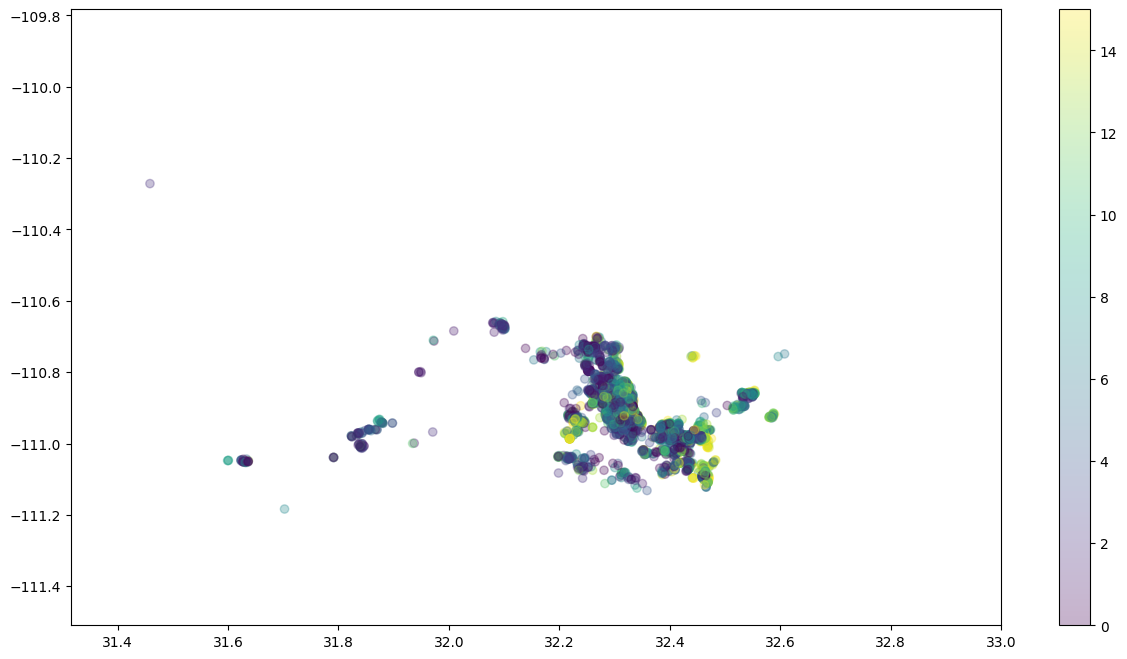

In [31]:
plt.figure(figsize=(15,8))
plt.scatter(df['latitude'],df['longitude'],c=df['region'],alpha=0.3,cmap='viridis')
plt.xlim(right=33.0)
plt.colorbar()
plt.show()

# Regression

In [32]:
class KNNRegressor():

  def fit(self, X, y):
    self.X=X
    self.y=y

  def predict(self, X, K, epsilon= 1e-3):

    N=len(X)
    y_hat = np.zeros(N)

    for i in range(N):
      dist2=np.sum((self.X-X[i])**2, axis=1)
      idxt = np.argsort(dist2)[:K]
      gamma_k = np.exp(-dist2[idxt])/(np.exp(-dist2[idxt]).sum()+epsilon)
      y_hat[i] = gamma_k.dot(self.y[idxt])

    return y_hat

In [33]:
target = df['sold_price'].values 
features = df[['latitude', 'longitude', 'bedrooms', 'bathrooms']].values
knn_reg = KNNRegressor()
knn_reg.fit(features, target)


In [34]:
y_pred = knn_reg.predict(features, K=10)

In [35]:
new_sample = np.array([[32.221680, -110.781160, 4, 2]])  # lat, long, bedrooms, bathrooms
predicted_price = knn_reg.predict(new_sample, K=10)
print(predicted_price)

[566650.16712935]


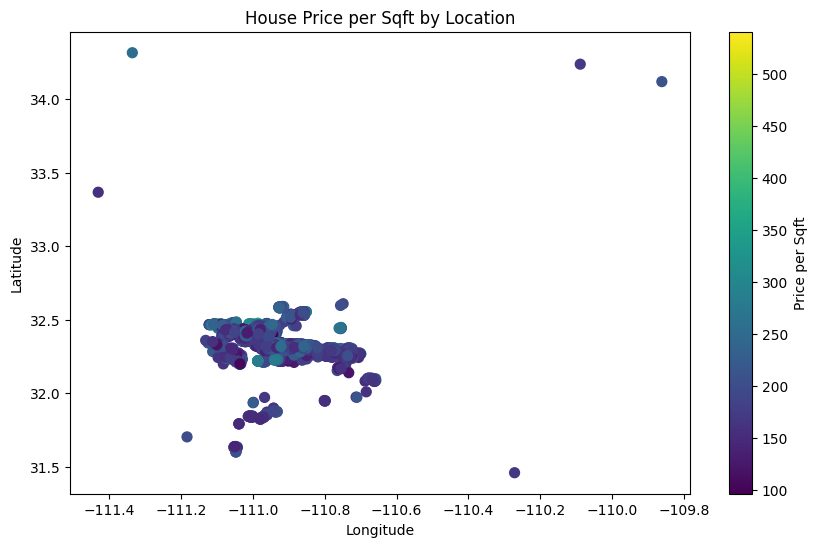

In [45]:

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['longitude'], df['latitude'], c=df['price_per_sqft'], cmap='viridis', s=50)
plt.colorbar(scatter, label='Price per Sqft')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('House Price per Sqft by Location')
plt.show()


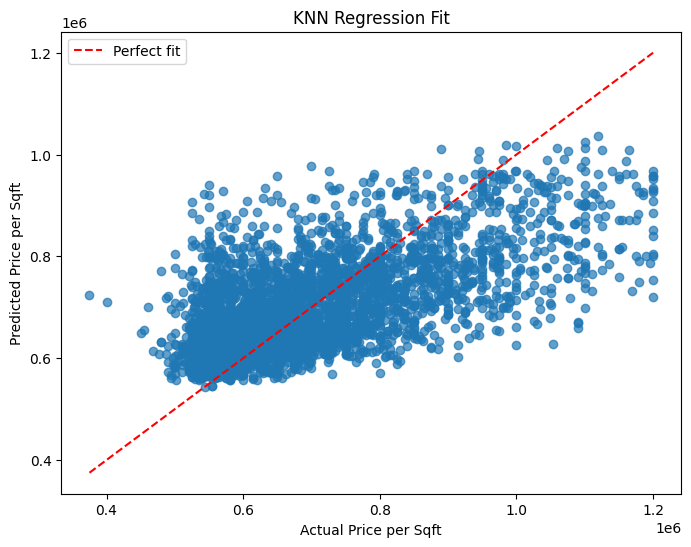

In [54]:
# Predict on training data
K = 10
y_pred = knn_reg.predict(features, K=K)

plt.figure(figsize=(8, 6))
plt.scatter(target, y_pred, alpha=0.7)
plt.plot([target.min(), target.max()], [target.min(), target.max()], 'r--', label='Perfect fit')
plt.xlabel('Actual Price per Sqft')
plt.ylabel('Predicted Price per Sqft')
plt.title('KNN Regression Fit')
plt.legend()
plt.show()


In [52]:
def OLS(Y,Y_hat):
  N = Y_hat.shape[0]
  return (1/(2*N))*np.sum((Y-Y_hat)**2)

In [55]:
OLS(target, y_pred)

np.float64(6469838403.665386)

In [56]:
target

array([1100000., 1200000., 1120150., ...,  535000.,  550000.,  550000.],
      shape=(3823,))

In [57]:
y_pred

array([853520.87113737, 839570.73006114, 912597.04129124, ...,
       604143.44428045, 644675.50254723, 684423.65841329], shape=(3823,))